# Занятие 31. Решающее дерево — presentation

Ноутбук для работы **у доски**. Полный текст: `Урок_31_Решающее_дерево.ipynb`.

Сквозной пример: подготовка + сон → сдал / не сдал.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = pd.DataFrame({
    'подготовка': [1, 2, 3, 4, 5, 6, 7, 8, 4, 6],
    'сон': [5, 8, 6, 7, 5, 8, 6, 9, 9, 4],
})
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0])  # 0 = не сдал, 1 = сдал

tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X, y)
print('Объектов:', len(X), '| признаков:', list(X.columns))
X


Объектов: 10 | признаков: ['подготовка', 'сон']


,подготовка,сон
0,1,5
1,2,8
2,3,6
3,4,7
4,5,5
5,6,8
6,7,6
7,8,9
8,4,9
9,6,4


## 1. Как устроено решающее дерево

**Обсудим:** чем дерево отличается от «одной прямой» логрегрессии?


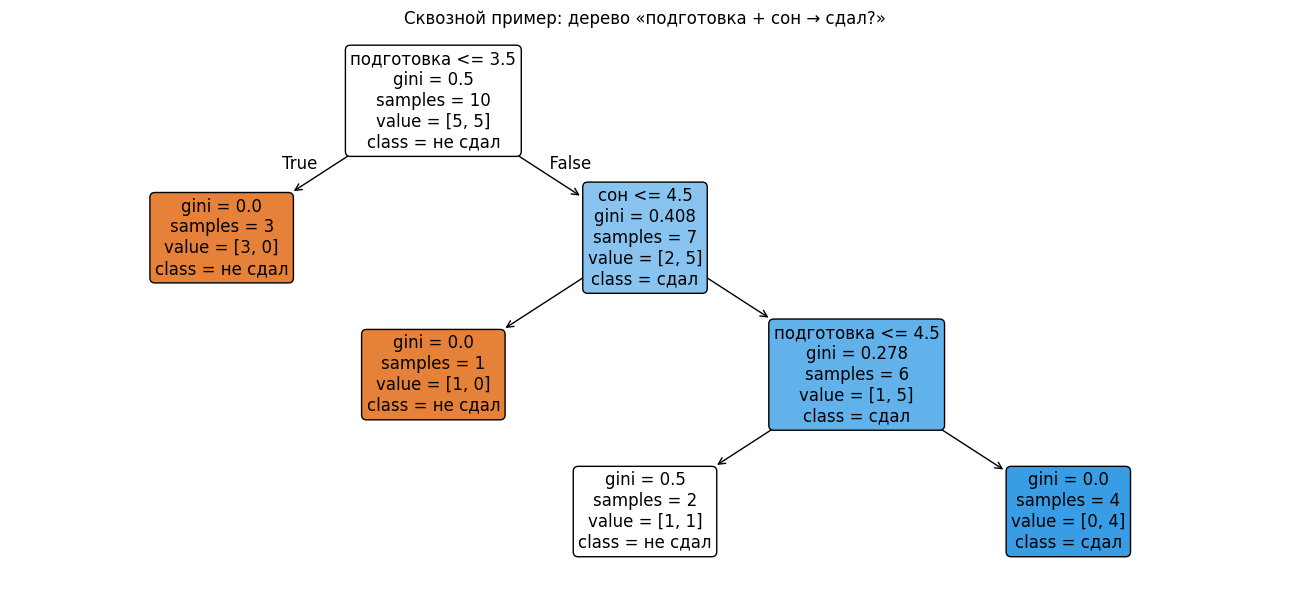


> **Вывод.** Дерево — цепочка вопросов «признак ≤ порог?» до ответа в **листе**.


## 2. Как алгоритм выбирает разбиение

**Обсудим:** откуда берутся кандидаты порогов?


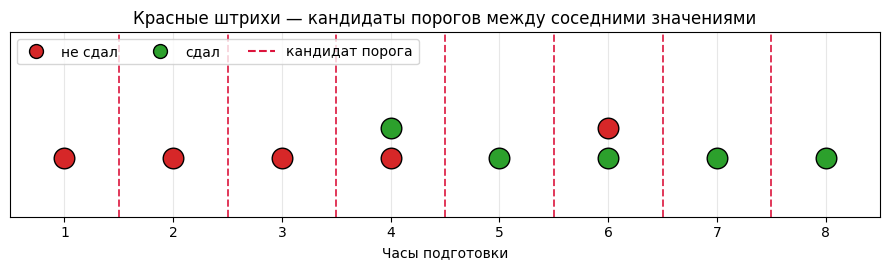


> **Вывод.** Берут середины между уникальными значениями признака и ищут порог с лучшим выигрышем.


## 3. Мера неопределённости Джини (Gini impurity)

**Обсудим:** когда Gini максимален — все одного класса или классы поровну?


In [4]:
def gini(labels):
    counts = np.bincount(labels)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

for labels in [np.array([0, 0, 0, 0]), np.array([0, 0, 0, 1]), np.array([0, 0, 1, 1])]:
    print(labels, 'Gini =', round(gini(labels), 3))


[0 0 0 0] Gini = 0.0
[0 0 0 1] Gini = 0.375
[0 0 1 1] Gini = 0.5


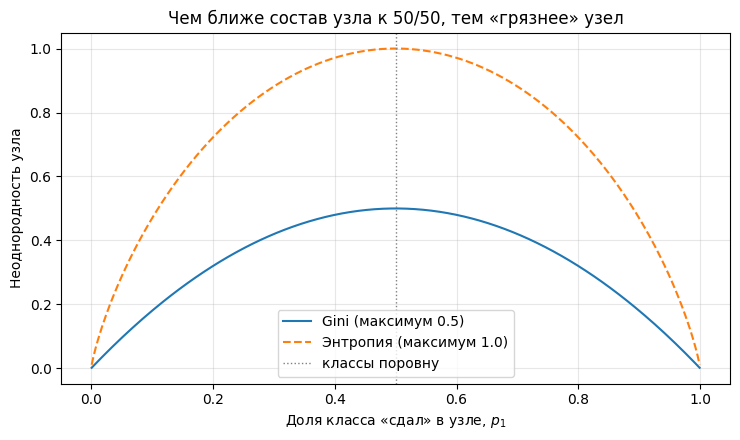


> **Вывод.** Gini = 0 в чистом узле; максимум при равной смеси классов.


## 4. Information gain — выигрыш от разбиения

**Обсудим:** какой сплит лучше — тот, что сильнее уменьшает средний Gini детей?


In [6]:
parent = np.array([0, 0, 0, 1, 1, 1])
splits = {
    'A: классы разделены': (np.array([0, 0, 0]), np.array([1, 1, 1])),
    'B: классы смешаны': (np.array([0, 0]), np.array([0, 1, 1, 1])),
}

def weighted_gini(left, right):
    n = len(left) + len(right)
    return (len(left) * gini(left) + len(right) * gini(right)) / n

parent_g = gini(parent)
for name, (L, R) in splits.items():
    split_g = weighted_gini(L, R)
    print(name, 'Gini_split =', round(split_g, 3), 'gain =', round(parent_g - split_g, 3))


A: классы разделены Gini_split = 0.0 gain = 0.5
B: классы смешаны Gini_split = 0.25 gain = 0.25


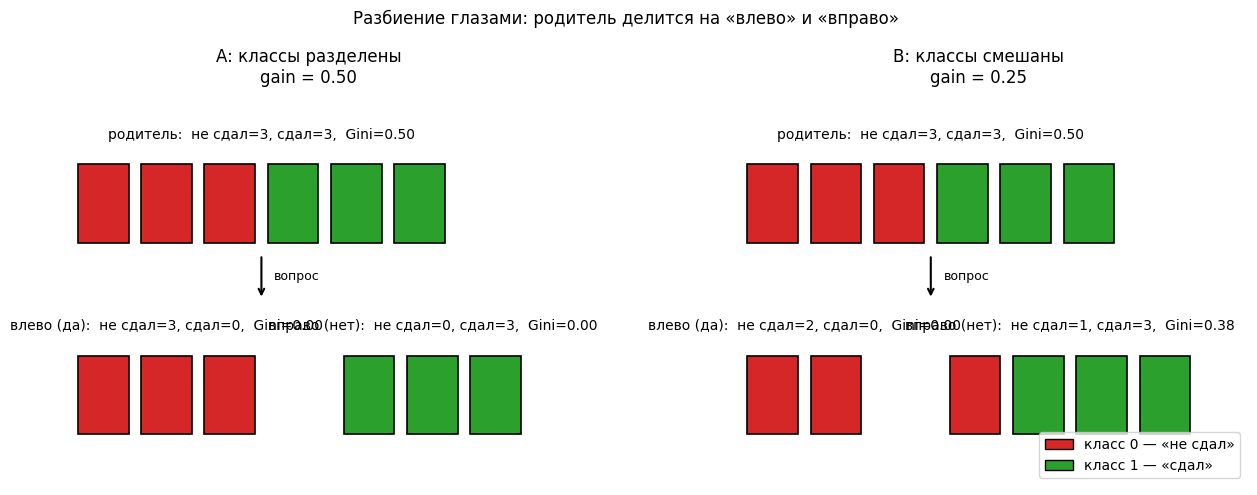


подготовка → пороги [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]
подготовка → gain   [0.056, 0.125, 0.214, 0.18, 0.083, 0.125, 0.056]
сон → пороги [4.5, 5.5, 6.5, 7.5, 8.5]
сон → gain   [0.056, 0.024, 0.02, 0.083, 0.125]


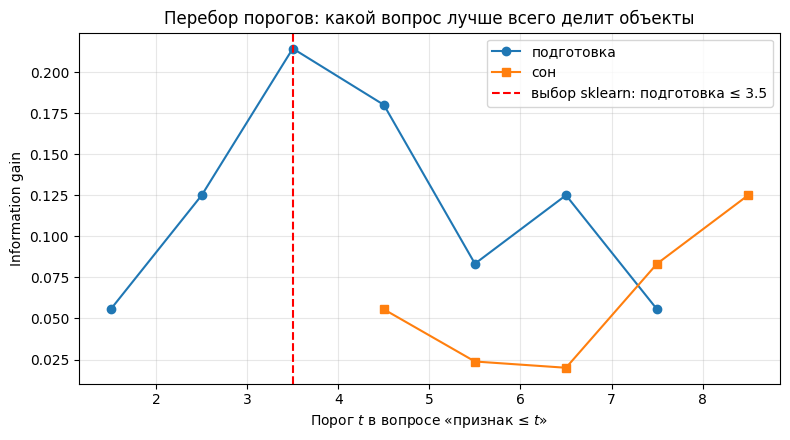

In [8]:
root_gini = gini(y)

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, marker in [('подготовка', 'o'), ('сон', 's')]:
    values = np.unique(X[col])
    thresholds = (values[:-1] + values[1:]) / 2      # середины между соседними значениями
    gains = []
    for t in thresholds:
        mask = X[col].values <= t
        gains.append(root_gini - weighted_gini(y[mask], y[~mask]))
    print(col, '→ пороги', [round(float(t), 1) for t in thresholds])
    print(col, '→ gain  ', [round(float(g), 3) for g in gains])
    ax.plot(thresholds, gains, marker=marker, label=col)

ax.axvline(3.5, color='red', linestyle='--', label='выбор sklearn: подготовка ≤ 3.5')
ax.set_xlabel('Порог $t$ в вопросе «признак ≤ $t$»')
ax.set_ylabel('Information gain')
ax.set_title('Перебор порогов: какой вопрос лучше всего делит объекты')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Обсудим:** что означают высокие точки на графике выигрыша?


> **Вывод.** Information gain — насколько вопрос очистил узлы. Алгоритм жадно берёт лучший выигрыш.


## 5. Энтропия *

**Обсудим:** зачем ещё одна мера, если есть Gini?


> **Вывод.** Энтропия — альтернативная мера «грязи»; на практике часто похожа на Gini. Подробности — в методичке.


## 6. Рекурсивное построение дерева

**Обсудим:** что меняется, когда разрешаем глубину 1, 2, 3?


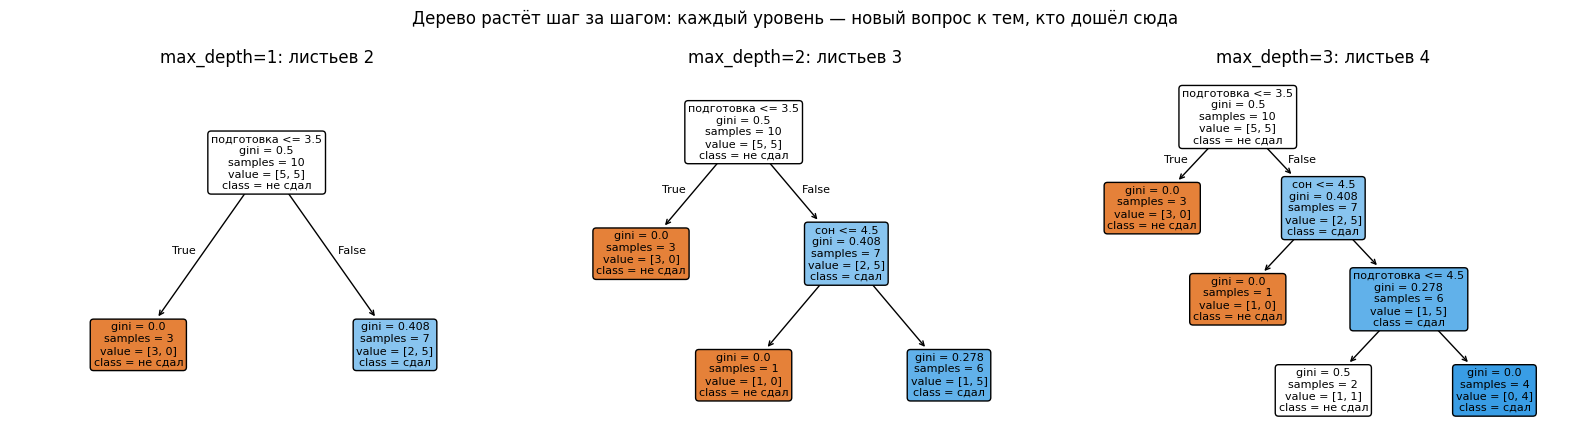

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, depth in zip(axes, [1, 2, 3]):
    step_tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X, y)
    plot_tree(step_tree, feature_names=list(X.columns), class_names=['не сдал', 'сдал'],
              filled=True, rounded=True, fontsize=8, ax=ax)
    ax.set_title(f'max_depth={depth}: листьев {step_tree.get_n_leaves()}')
fig.suptitle('Дерево растёт шаг за шагом: каждый уровень — новый вопрос к тем, кто дошёл сюда')
plt.tight_layout()
plt.show()


> **Вывод.** Дерево растёт рекурсивно: после каждого вопроса — новые вопросы в детях, пока не лист.


## 7. MSE как критерий разбиения в регрессии

**Обсудим:** в регрессии вместо Gini что минимизируют?


In [10]:
y_reg = np.array([5., 5., 6., 9., 9., 10.])
parent_mse = np.mean((y_reg - y_reg.mean()) ** 2)
left, right = y_reg[:3], y_reg[3:]
split_mse = (
    len(left) / len(y_reg) * np.mean((left - left.mean()) ** 2)
    + len(right) / len(y_reg) * np.mean((right - right.mean()) ** 2)
)
print('MSE до разбиения:', round(parent_mse, 2))
print('Прогноз до разбиения (среднее):', round(y_reg.mean(), 2))
print('MSE после разбиения 3+3:', round(split_mse, 2))
print('Прогноз левого листа (среднее):', round(left.mean(), 2))
print('Прогноз правого листа (среднее):', round(right.mean(), 2))


MSE до разбиения: 4.22
Прогноз до разбиения (среднее): 7.33
MSE после разбиения 3+3: 0.22
Прогноз левого листа (среднее): 5.33
Прогноз правого листа (среднее): 9.33


max_depth=2: прогноз при x=6 → -0.917, при x=100 → -0.917
max_depth=5: прогноз при x=6 → -0.969, при x=100 → -0.969


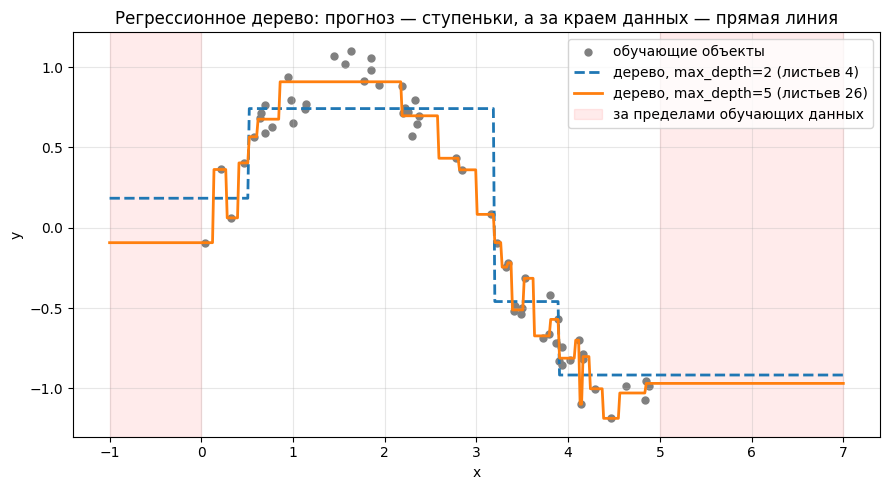

In [11]:
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(42)
x_train = np.sort(rng.uniform(0, 5, 60))
y_train = np.sin(x_train) + rng.normal(0, 0.15, 60)

x_plot = np.linspace(-1, 7, 500)          # шире, чем train, — чтобы увидеть экстраполяцию

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_train, y_train, s=25, color='gray', label='обучающие объекты')
for depth, style in [(2, '--'), (5, '-')]:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(x_train.reshape(-1, 1), y_train)
    ax.plot(x_plot, reg.predict(x_plot.reshape(-1, 1)), style, linewidth=2,
            label=f'дерево, max_depth={depth} (листьев {reg.get_n_leaves()})')
    print(f'max_depth={depth}: прогноз при x=6 → {reg.predict([[6]])[0]:.3f}, '
          f'при x=100 → {reg.predict([[100]])[0]:.3f}')
ax.axvspan(-1, 0, color='red', alpha=0.08)
ax.axvspan(5, 7, color='red', alpha=0.08, label='за пределами обучающих данных')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Регрессионное дерево: прогноз — ступеньки, а за краем данных — прямая линия')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


> **Вывод.** В регрессии сплит уменьшает **MSE**; прогноз в листе — среднее целей листа (лестница).


## 8. Прогноз в листе


In [12]:
new = pd.DataFrame({
    'подготовка': [3, 7, 4],
    'сон':        [8, 5, 7],
})
proba = tree.predict_proba(new)

result = pd.DataFrame({
    'подготовка': new['подготовка'],
    'сон': new['сон'],
    'P(не сдал)': proba[:, 0],
    'P(сдал)': proba[:, 1],
    'прогноз': np.where(tree.predict(new) == 1, 'сдал', 'не сдал'),
})
print(result.to_string(index=False))


 подготовка  сон  P(не сдал)  P(сдал) прогноз
          3    8         1.0      0.0 не сдал
          7    5         0.0      1.0    сдал
          4    7         0.5      0.5 не сдал


> **Вывод.** Классификация: доля классов в листе / метка большинства. Уверенность связана с чистотой листа.


## 9. Путь одного объекта

**Обсудим:** всегда ли дереву нужны все вопросы для каждого ученика?


In [13]:
def explain_if_then(tree, x_row, feature_names, class_names):
    node = 0
    step = 1
    while tree.tree_.feature[node] >= 0:                 # пока это не лист
        name = feature_names[tree.tree_.feature[node]]
        threshold = tree.tree_.threshold[node]
        value = x_row[name]                              # берём признак по имени, а не по номеру
        if value <= threshold:
            print(f'{step}. ЕСЛИ {name} ≤ {threshold:.1f}  (у студента {value}) → да, влево')
            node = tree.tree_.children_left[node]
        else:
            print(f'{step}. ЕСЛИ {name} > {threshold:.1f}  (у студента {value}) → нет, вправо')
            node = tree.tree_.children_right[node]
        step += 1
    leaf_shares = tree.tree_.value[node][0]              # доли классов в листе (sklearn ≥ 1.3)
    pred_idx = int(np.argmax(leaf_shares))
    print(f'{step}. ИТОГ: лист → прогноз «{class_names[pred_idx]}»  '
          f'(доли классов {leaf_shares.round(2)}, объектов в листе {tree.tree_.n_node_samples[node]})')

for i in [0, 1]:
    sample = new.iloc[i]
    prep, sleep = sample['подготовка'], sample['сон']
    print(f'Студент {i + 1}: подготовка = {prep}, сон = {sleep}')
    print('--- правила «если — то» ---')
    explain_if_then(tree, sample, list(X.columns), ['не сдал', 'сдал'])
    print()


Студент 1: подготовка = 3, сон = 8
--- правила «если — то» ---
1. ЕСЛИ подготовка ≤ 3.5  (у студента 3) → да, влево
2. ИТОГ: лист → прогноз «не сдал»  (доли классов [1. 0.], объектов в листе 3)

Студент 2: подготовка = 7, сон = 5
--- правила «если — то» ---
1. ЕСЛИ подготовка > 3.5  (у студента 7) → нет, вправо
2. ЕСЛИ сон > 4.5  (у студента 5) → нет, вправо
3. ЕСЛИ подготовка > 4.5  (у студента 7) → нет, вправо
4. ИТОГ: лист → прогноз «сдал»  (доли классов [0. 1.], объектов в листе 4)



> **Вывод.** Путь — цепочка сработавших условий. Ветви разной длины нормальны.


## 10. Ступенчатая граница решений

**Обсудим:** почему граница дерева — «лестница», а не гладкая кривая?


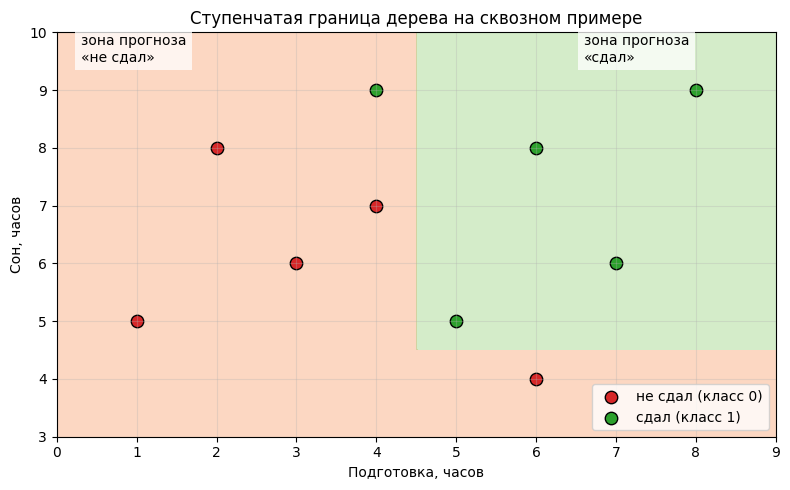

In [14]:
x1 = np.linspace(0, 9, 200)
x2 = np.linspace(3, 10, 200)
xx1, xx2 = np.meshgrid(x1, x2)
grid = pd.DataFrame({'подготовка': xx1.ravel(), 'сон': xx2.ravel()})
zones = tree.predict(grid).reshape(xx1.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.contourf(xx1, xx2, zones, levels=[-0.5, 0.5, 1.5], cmap='RdYlGn', alpha=0.35)
ax.scatter(X.loc[y == 0, 'подготовка'], X.loc[y == 0, 'сон'],
           c='tab:red', edgecolor='black', s=80, label='не сдал (класс 0)')
ax.scatter(X.loc[y == 1, 'подготовка'], X.loc[y == 1, 'сон'],
           c='tab:green', edgecolor='black', s=80, label='сдал (класс 1)')
ax.text(0.3, 9.5, 'зона прогноза\n«не сдал»', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
ax.text(6.6, 9.5, 'зона прогноза\n«сдал»', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
ax.set_xlabel('Подготовка, часов')
ax.set_ylabel('Сон, часов')
ax.set_title('Ступенчатая граница дерева на сквозном примере')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


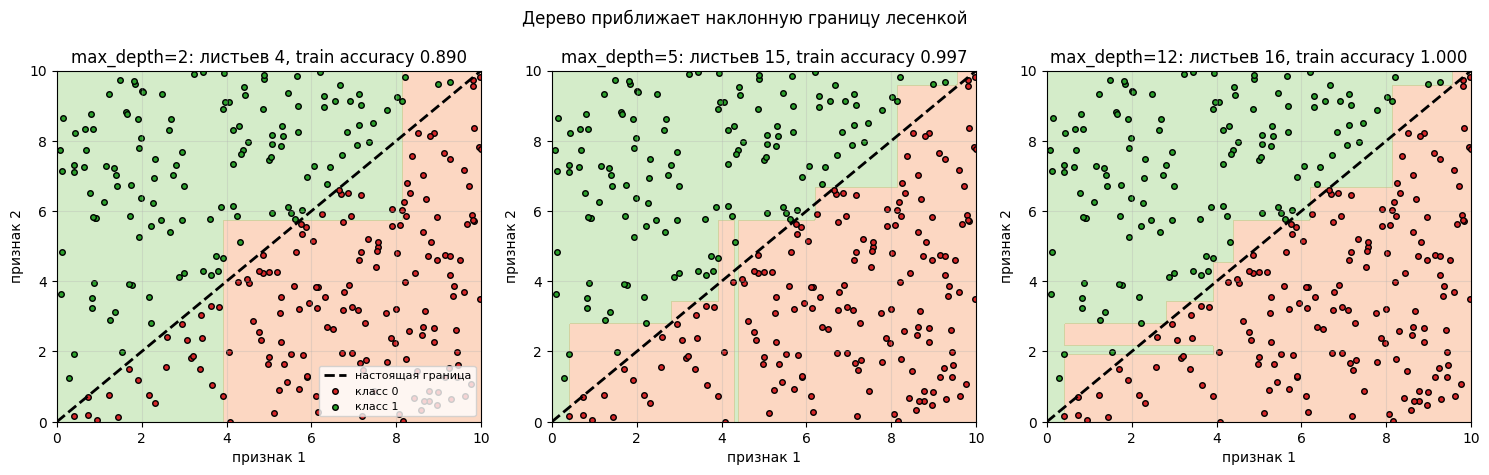

In [15]:
rng = np.random.default_rng(0)
Xd = rng.uniform(0, 10, size=(300, 2))
yd = (Xd[:, 1] > Xd[:, 0]).astype(int)          # истинная граница — диагональ x2 = x1

gx, gy = np.meshgrid(np.linspace(0, 10, 300), np.linspace(0, 10, 300))
grid_diag = np.c_[gx.ravel(), gy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, depth in zip(axes, [2, 5, 12]):
    model = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(Xd, yd)
    ax.contourf(gx, gy, model.predict(grid_diag).reshape(gx.shape),
                levels=[-0.5, 0.5, 1.5], cmap='RdYlGn', alpha=0.35)
    ax.plot([0, 10], [0, 10], 'k--', linewidth=2, label='настоящая граница')
    ax.scatter(Xd[yd == 0, 0], Xd[yd == 0, 1], c='tab:red', edgecolor='black', s=16, label='класс 0')
    ax.scatter(Xd[yd == 1, 0], Xd[yd == 1, 1], c='tab:green', edgecolor='black', s=16, label='класс 1')
    ax.set_title(f'max_depth={depth}: листьев {model.get_n_leaves()}, '
                 f'train accuracy {model.score(Xd, yd):.3f}')
    ax.set_xlabel('признак 1')
    ax.set_ylabel('признак 2')
    ax.grid(alpha=0.3)
axes[0].legend(loc='lower right', fontsize=8)
fig.suptitle('Дерево приближает наклонную границу лесенкой')
plt.tight_layout()
plt.show()


> **Вывод.** Каждый вопрос — горизонтальный/вертикальный разрез. Диагональ приближают ступеньками.


## 11. Переобучение дерева

**Обсудим:** если увеличить `max_depth`, train-accuracy вырастет. А validation?


train: 227 объектов | validation: 123 объектов


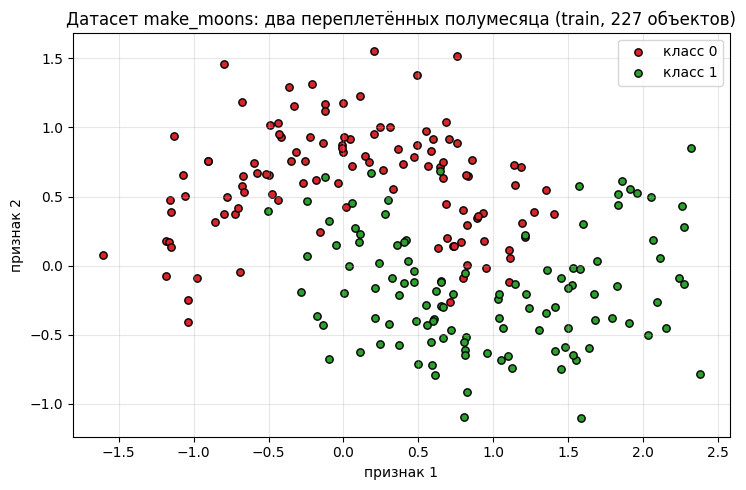

In [16]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Xm, ym = make_moons(n_samples=350, noise=0.3, random_state=42)
Xt, Xv, yt, yv = train_test_split(Xm, ym, test_size=0.35, stratify=ym, random_state=42)
print('train:', len(Xt), 'объектов | validation:', len(Xv), 'объектов')

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(Xt[yt == 0, 0], Xt[yt == 0, 1], c='tab:red', edgecolor='black', s=28, label='класс 0')
ax.scatter(Xt[yt == 1, 0], Xt[yt == 1, 1], c='tab:green', edgecolor='black', s=28, label='класс 1')
ax.set_xlabel('признак 1')
ax.set_ylabel('признак 2')
ax.set_title(f'Датасет make_moons: два переплетённых полумесяца (train, {len(Xt)} объектов)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


max_depth= 1  train=0.814  validation=0.803
max_depth= 2  train=0.896  validation=0.880
max_depth= 3  train=0.899  validation=0.876
max_depth= 4  train=0.911  validation=0.876
max_depth= 5  train=0.942  validation=0.868
max_depth= 6  train=0.953  validation=0.864
max_depth= 7  train=0.971  validation=0.859
max_depth= 8  train=0.981  validation=0.862
max_depth= 9  train=0.990  validation=0.857
max_depth=10  train=0.996  validation=0.859
max_depth=11  train=0.998  validation=0.855
max_depth=12  train=1.000  validation=0.854
max_depth=13  train=1.000  validation=0.856
max_depth=14  train=1.000  validation=0.856
max_depth=15  train=1.000  validation=0.856


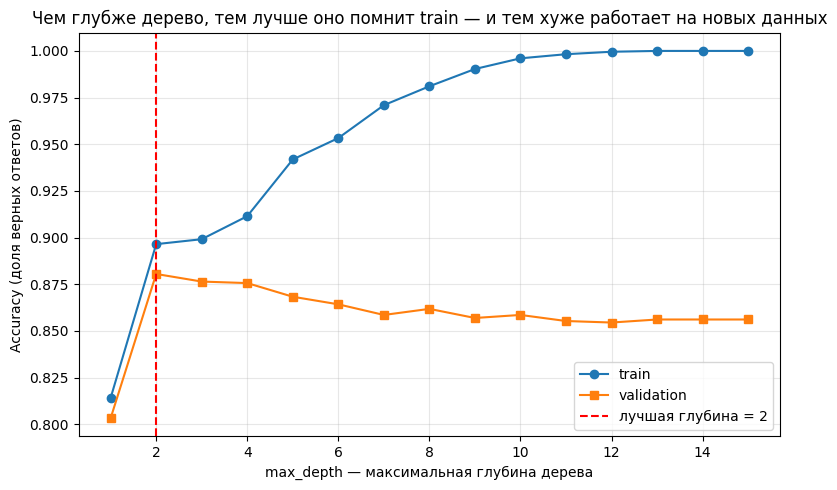

In [17]:
depths = range(1, 16)
train_acc, val_acc = np.zeros(len(depths)), np.zeros(len(depths))
n_runs = 10

for seed in range(n_runs):                      # усредняем, чтобы убрать случайные скачки
    Xs, ys = make_moons(n_samples=350, noise=0.3, random_state=seed)
    Xts, Xvs, yts, yvs = train_test_split(Xs, ys, test_size=0.35, stratify=ys, random_state=seed)
    for i, d in enumerate(depths):
        model = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xts, yts)
        train_acc[i] += accuracy_score(yts, model.predict(Xts))
        val_acc[i] += accuracy_score(yvs, model.predict(Xvs))

train_acc /= n_runs
val_acc /= n_runs
best = list(depths)[int(np.argmax(val_acc))]
for d, tr, va in zip(depths, train_acc, val_acc):
    print(f'max_depth={d:2d}  train={tr:.3f}  validation={va:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_acc, marker='o', label='train')
ax.plot(depths, val_acc, marker='s', label='validation')
ax.axvline(best, color='red', linestyle='--', label=f'лучшая глубина = {best}')
ax.set_xlabel('max_depth — максимальная глубина дерева')
ax.set_ylabel('Accuracy (доля верных ответов)')
ax.set_title('Чем глубже дерево, тем лучше оно помнит train — и тем хуже работает на новых данных')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Обсудим:** что видно на кривых глубины?


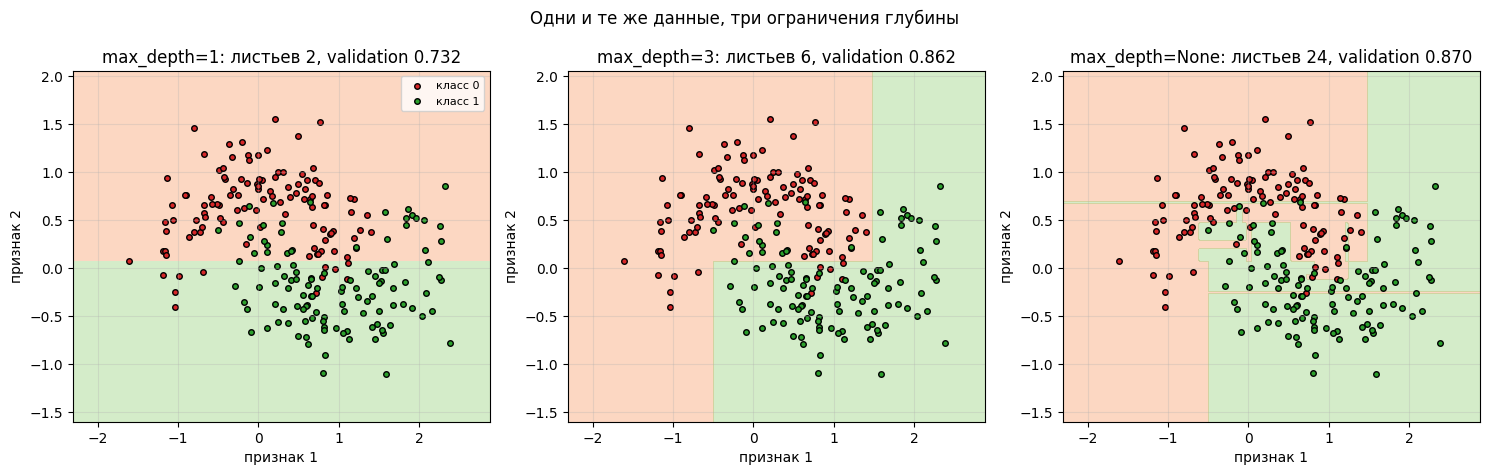

In [18]:
gx, gy = np.meshgrid(np.linspace(Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5, 300),
                     np.linspace(Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5, 300))
grid_moons = np.c_[gx.ravel(), gy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, depth in zip(axes, [1, 3, None]):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(Xt, yt)
    ax.contourf(gx, gy, model.predict(grid_moons).reshape(gx.shape),
                levels=[-0.5, 0.5, 1.5], cmap='RdYlGn', alpha=0.35)
    ax.scatter(Xt[yt == 0, 0], Xt[yt == 0, 1], c='tab:red', edgecolor='black', s=16, label='класс 0')
    ax.scatter(Xt[yt == 1, 0], Xt[yt == 1, 1], c='tab:green', edgecolor='black', s=16, label='класс 1')
    ax.set_title(f'max_depth={depth}: листьев {model.get_n_leaves()}, '
                 f'validation {accuracy_score(yv, model.predict(Xv)):.3f}')
    ax.set_xlabel('признак 1')
    ax.set_ylabel('признак 2')
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=8)
fig.suptitle('Одни и те же данные, три ограничения глубины')
plt.tight_layout()
plt.show()


**Обсудим:** `min_samples_leaf` и `ccp_alpha` — зачем оба рычага?


In [19]:
for msl in [1, 5, 20, 50]:
    model = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42).fit(Xt, yt)
    print(
        f'min_samples_leaf={msl:2d}  листьев={model.get_n_leaves():3d}  '
        f'глубина={model.get_depth()}  '
        f'train={accuracy_score(yt, model.predict(Xt)):.3f}  '
        f'validation={accuracy_score(yv, model.predict(Xv)):.3f}'
    )


min_samples_leaf= 1  листьев= 24  глубина=9  train=1.000  validation=0.870
min_samples_leaf= 5  листьев= 17  глубина=6  train=0.969  validation=0.854
min_samples_leaf=20  листьев=  7  глубина=4  train=0.850  validation=0.813
min_samples_leaf=50  листьев=  3  глубина=2  train=0.824  validation=0.732


In [20]:
for alpha in [0.0, 0.005, 0.02, 0.08]:
    pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42).fit(Xt, yt)
    print(
        f'ccp_alpha={alpha:.3f}  листьев={pruned.get_n_leaves():3d}  '
        f'глубина={pruned.get_depth()}  validation={accuracy_score(yv, pruned.predict(Xv)):.3f}'
    )


ccp_alpha=0.000  листьев= 24  глубина=9  validation=0.870
ccp_alpha=0.005  листьев= 12  глубина=5  validation=0.870
ccp_alpha=0.020  листьев=  7  глубина=5  validation=0.902
ccp_alpha=0.080  листьев=  2  глубина=1  validation=0.732


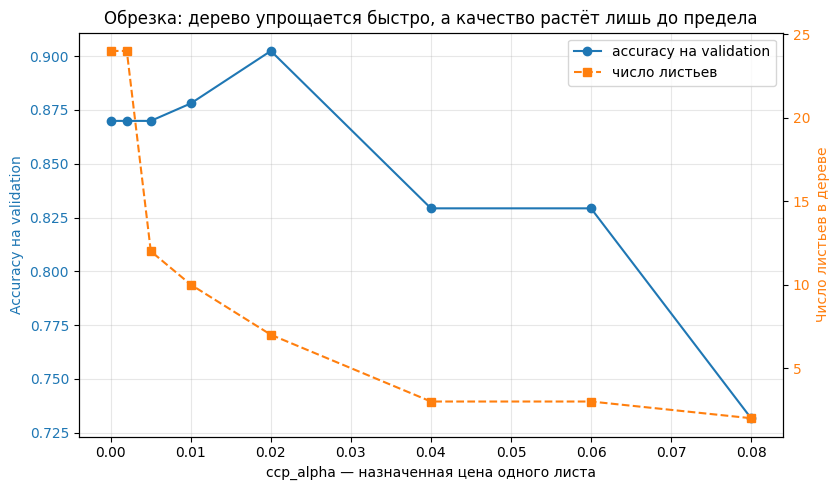

In [21]:
alphas = [0.0, 0.002, 0.005, 0.01, 0.02, 0.04, 0.06, 0.08]
val_scores, leaf_counts = [], []
for alpha in alphas:
    pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42).fit(Xt, yt)
    val_scores.append(accuracy_score(yv, pruned.predict(Xv)))
    leaf_counts.append(pruned.get_n_leaves())

fig, ax = plt.subplots(figsize=(8.5, 5))
line_acc, = ax.plot(alphas, val_scores, marker='o', color='tab:blue',
                    label='accuracy на validation')
ax.set_xlabel('ccp_alpha — назначенная цена одного листа')
ax.set_ylabel('Accuracy на validation', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax.grid(alpha=0.3)

ax_leaves = ax.twinx()
line_leaves, = ax_leaves.plot(alphas, leaf_counts, marker='s', linestyle='--',
                              color='tab:orange', label='число листьев')
ax_leaves.set_ylabel('Число листьев в дереве', color='tab:orange')
ax_leaves.tick_params(axis='y', labelcolor='tab:orange')

ax.set_title('Обрезка: дерево упрощается быстро, а качество растёт лишь до предела')
ax.legend(handles=[line_acc, line_leaves], loc='upper right')
plt.tight_layout()
plt.show()


> **Вывод.** Глубокое дерево запоминает шум. Ограничивают `max_depth`, `min_samples_leaf`, обрезкой `ccp_alpha`.


## 12. Предобработка данных для дерева

**Обсудим:** нужно ли применять стандартизацию в kNN? а в деревьях? в чём отличие?


In [22]:
from sklearn.tree import export_text

tree_scaled = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X * 100, y)

print('Дерево на исходных данных:')
print(export_text(tree, feature_names=list(X.columns)))
print('Дерево на тех же данных, умноженных на 100:')
print(export_text(tree_scaled, feature_names=list(X.columns)))
print('Прогнозы совпадают:', np.array_equal(tree.predict(X), tree_scaled.predict(X * 100)))


Дерево на исходных данных:
|--- подготовка <= 3.50
|   |--- class: 0
|--- подготовка >  3.50
|   |--- сон <= 4.50
|   |   |--- class: 0
|   |--- сон >  4.50
|   |   |--- подготовка <= 4.50
|   |   |   |--- class: 0
|   |   |--- подготовка >  4.50
|   |   |   |--- class: 1

Дерево на тех же данных, умноженных на 100:
|--- подготовка <= 350.00
|   |--- class: 0
|--- подготовка >  350.00
|   |--- сон <= 450.00
|   |   |--- class: 0
|   |--- сон >  450.00
|   |   |--- подготовка <= 450.00
|   |   |   |--- class: 0
|   |   |--- подготовка >  450.00
|   |   |   |--- class: 1

Прогнозы совпадают: True


> **Вывод.** Дереву scaler **не нужен**: оно сравнивает признак с порогом, единицы не важны.


## 13. Важность признаков

**Обсудим:** impurity importance vs permutation — кому доверять осторожнее при коррелированных признаках?


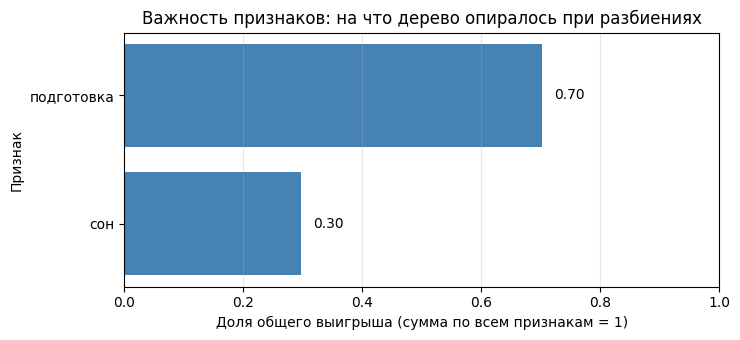

In [23]:
importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.barh(importances.index, importances.values, color='steelblue')
for i, v in enumerate(importances.values):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center')
ax.set_xlabel('Доля общего выигрыша (сумма по всем признакам = 1)')
ax.set_ylabel('Признак')
ax.set_title('Важность признаков: на что дерево опиралось при разбиениях')
ax.set_xlim(0, 1)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


In [24]:
from sklearn.inspection import permutation_importance

model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(Xt, yt)
perm = permutation_importance(model, Xv, yv, n_repeats=30, random_state=42)   # именно validation!

comparison = pd.DataFrame(
    {'impurity (по train)': model.feature_importances_,
     'permutation (по validation)': perm.importances_mean},
    index=['признак 1', 'признак 2'],
)
print('Accuracy этой модели на validation:', round(accuracy_score(yv, model.predict(Xv)), 3))
print(comparison.round(3))


Accuracy этой модели на validation: 0.87
           impurity (по train)  permutation (по validation)
признак 1                0.418                        0.212
признак 2                0.582                        0.238


> **Вывод.** Impurity — по выигрышам сплитов; permutation — насколько ломается качество при перемешивании.
> При корреляциях смотрите оба, permutation часто честнее для интерпретации.


## 14. Почему одиночное дерево редко используют в реальных продуктах

**Обсудим:** чуть изменили bootstrap-выборку — что случится с верхним вопросом?


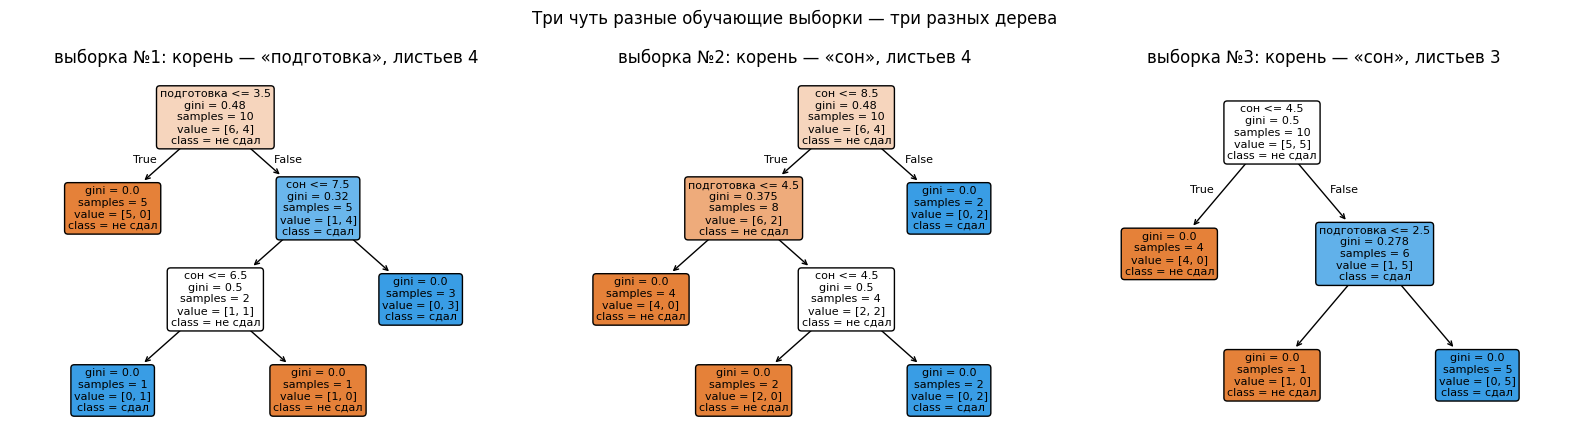

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for number, (ax, seed) in enumerate(zip(axes, [0, 1, 4]), start=1):
    idx = np.random.default_rng(seed).choice(len(X), size=len(X), replace=True)
    shaken = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X.iloc[idx], y[idx])
    plot_tree(shaken, feature_names=list(X.columns), class_names=['не сдал', 'сдал'],
              filled=True, rounded=True, fontsize=8, ax=ax)
    root_feature = list(X.columns)[shaken.tree_.feature[0]]
    ax.set_title(f'выборка №{number}: корень — «{root_feature}», '
                 f'листьев {shaken.get_n_leaves()}')
fig.suptitle('Три чуть разные обучающие выборки — три разных дерева')
plt.tight_layout()
plt.show()


> **Вывод.** Одиночное дерево **нестабильно**: маленькое изменение данных → другие вопросы. Дальше — ансамбли.


## 15. Когда одно дерево всё-таки уместно

**Обсудим:** назовите ситуацию, где объяснимое дерево лучше «чёрного ящика».


> **Вывод.** Нужны явные правила, быстрый baseline или инсайт по взаимодействиям — тогда неглубокое дерево уместно.


## Устно в конце

1. Чем Gini отличается в чистом и смешанном узле?
2. Нужен ли StandardScaler дереву?
3. Какой гиперпараметр крутить первым против переобучения?
4. Почему одно дерево редко в проде?
